In [1]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('HQ_Data_Clean_new.csv')

df= df.drop(columns=['subject_sp_id'])



In [2]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
# Convert to NumPy arrays if needed (GMM requires numerical input)
train_set = train_set.to_numpy()
test_set = test_set.to_numpy()

In [3]:
# Define and fit the GMM
n_components =  4 # Adjust the number of clusters as needed
gmm = GaussianMixture(n_components=n_components, init_params='k-means++', random_state=42)
train_clusters = gmm.fit_predict(train_set)

# Apply the trained model to the test set
test_clusters = gmm.predict(test_set)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components)
train_set_2d = pca.fit_transform(train_set)


C:\Users\B00804975\AppData\Local\Temp\ipykernel_19256\1847227363.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20' if n_components > 10 else 'tab10', n_components)


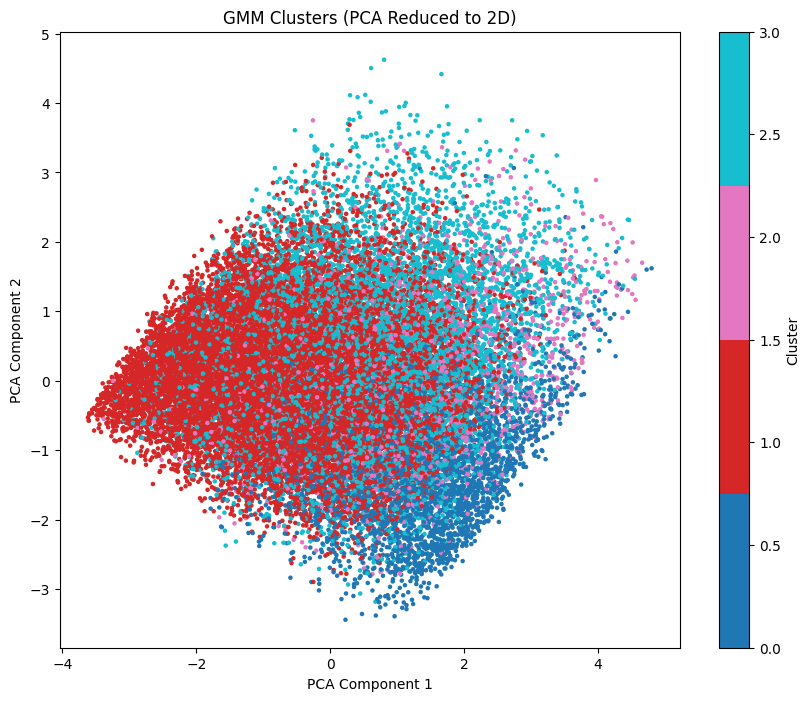

In [5]:
from matplotlib import cm
plt.figure(figsize=(10, 8))
cmap = cm.get_cmap('tab20' if n_components > 10 else 'tab10', n_components)
scatter = plt.scatter(train_set_2d[:, 0], train_set_2d[:, 1], c=train_clusters, cmap=cmap, s=5)
plt.colorbar(scatter, label="Cluster")
plt.title("GMM Clusters (PCA Reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
#plt.savefig("GMM_PCA.pdf", format="pdf", bbox_inches="tight")
plt.show()

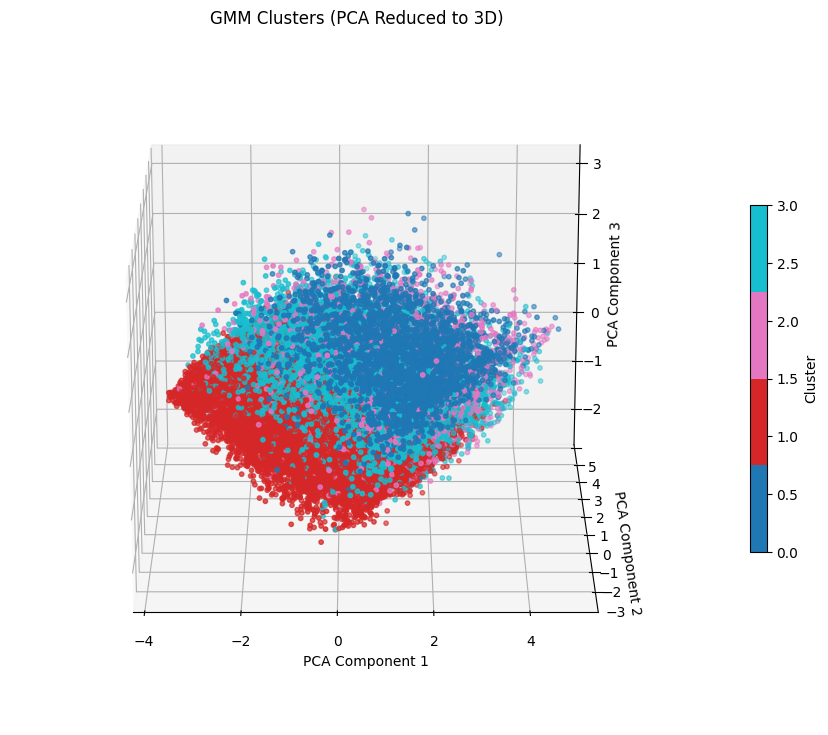

In [6]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
train_set_3d = pca.fit_transform(train_set)


fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    train_set_3d[:, 0], train_set_3d[:, 1], train_set_3d[:, 2],
    c=train_clusters, cmap=cmap, s=10
)


ax.view_init(elev=20, azim=-90)

fig.colorbar(scatter, label="Cluster", shrink=0.5)
ax.set_title("GMM Clusters (PCA Reduced to 3D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")


#plt.savefig("GMM_PCA_3D.pdf", format="pdf", bbox_inches="tight")
plt.show()

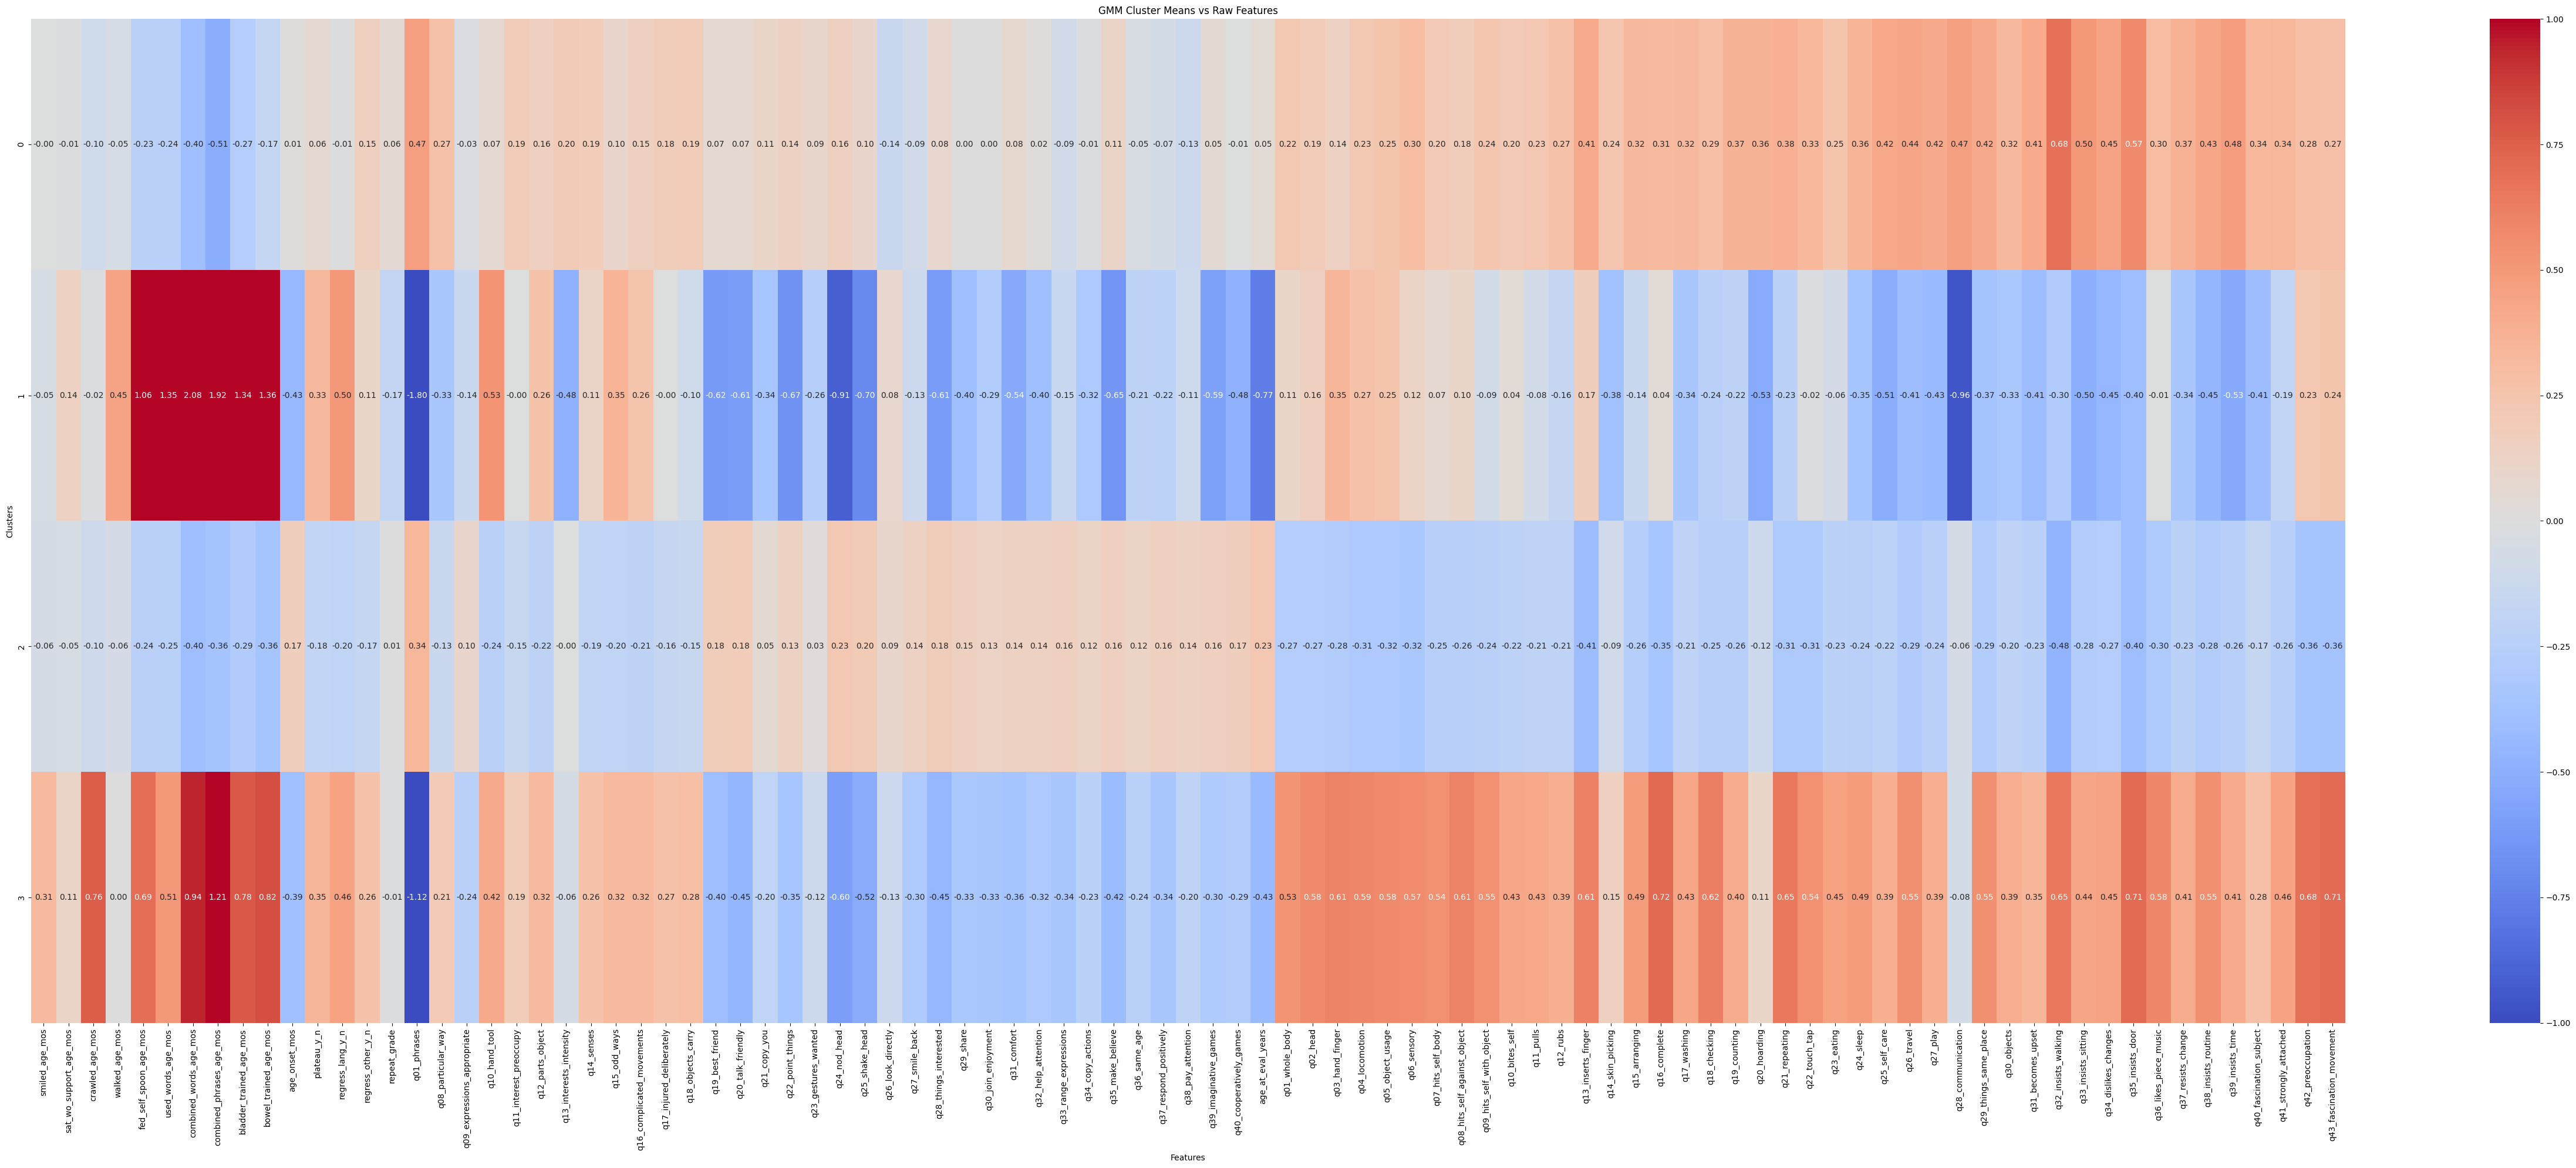

In [7]:
from sklearn.preprocessing import StandardScaler
# 1. Prepare your data
X = df.values  # your original features
feature_names = df.columns

# 2. Scale the features (important for GMM and comparability)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fit GMM
gmm = GaussianMixture(n_components, random_state=42)
gmm.fit(X_scaled)

# 4. Get means (cluster centers in feature space)
gmm_means = gmm.means_  # shape: (n_clusters, n_features)

# 5. Convert to DataFrame for plotting
means_df = pd.DataFrame(gmm_means, columns=feature_names)
means_df.index.name = 'Cluster'

# 6. Plot heatmap
plt.figure(figsize=(50, 20))
sns.heatmap(means_df, cmap='coolwarm', center=0, annot=True, fmt=".2f", vmin=-1, vmax=1)
plt.title('GMM Cluster Means vs Raw Features')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.tight_layout()
plt.show()

In [8]:
log_likelihood = gmm.score(test_set)  # Average log-likelihood per sample
print(f"Log-Likelihood Score: {log_likelihood:.2f}")

print(f"AIC: {gmm.aic(train_set)}, BIC: {gmm.bic(train_set)}")

Log-Likelihood Score: -89.41
AIC: 5284278.626825843, BIC: 5432283.09773889


In [9]:
n_components_range = range(1, 15)  # Try from 1 to 15 clusters
n_runs = 10  # number of repetitions

avg_log_likelihoods = []
avg_aic_scores = []
avg_bic_scores = []

for n in n_components_range:
    run_log_likelihoods = []
    run_aic_scores = []
    run_bic_scores = []
    
    for run in range(n_runs):
        gmm = GaussianMixture(n_components=n, random_state=None)  # no fixed state  random_state
        gmm.fit(train_set)
        
        # Store run results
        run_log_likelihoods.append(gmm.score(test_set))  # Average log-likelihood per sample
        run_aic_scores.append(gmm.aic(test_set))
        run_bic_scores.append(gmm.bic(test_set))
    
    # Store averages for this n
    avg_log_likelihoods.append(np.mean(run_log_likelihoods))
    avg_aic_scores.append(np.mean(run_aic_scores))
    avg_bic_scores.append(np.mean(run_bic_scores))
# For GMMs log-likelihood can be negative OR positive because GMM uses probability densities (not probabilities). 
# Densities can exceed 1 for narrow Gaussians, so log(p(x)) may be > 0. What matters is relative values (higher = better fit).

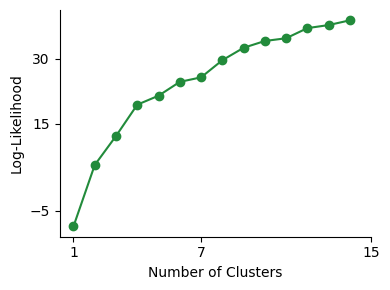

In [10]:
# --- First plot: Log-likelihood ---
plt.figure(figsize=(4, 3))
plt.plot(n_components_range, avg_log_likelihoods, marker='o', color="#228b3b")
plt.xlabel("Number of Clusters")
plt.ylabel("Log-Likelihood")
plt.xticks([1,7,15])
plt.yticks([-5,15,30])

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("GMM_elbow.svg", format="svg", bbox_inches="tight")
plt.show()

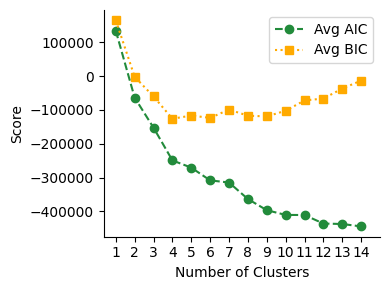

In [11]:
# --- Second plot: AIC and BIC ---
plt.figure(figsize=(4, 3))
plt.plot(n_components_range, avg_aic_scores, marker='o', label="Avg AIC", linestyle='dashed',color="#228b3b")
plt.plot(n_components_range, avg_bic_scores, marker='s', label="Avg BIC", linestyle='dotted',color="#ffaa00")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.xticks([1,7,15])
plt.legend()
plt.xticks(range(1, 15))


# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("GMM_AIC_BIC.svg", format="svg", bbox_inches="tight")
plt.show()

In [12]:
n_splits = 30
input_dim = df.shape[1]

avg_log_likelihoods = []   # per-sample average
total_log_likelihoods = [] # total log-likelihood

for i in range(n_splits):
    print(f"Split {i+1}/{n_splits}")
    train_data, val_data = train_test_split(df, test_size=0.2, random_state=None)

    # Fit GMM
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(train_data)

    # Compute average log-likelihood per sample
    avg_ll = gmm.score(train_data)


    # Store results
    avg_log_likelihoods.append(avg_ll)

Split 1/30
Split 2/30
Split 3/30
Split 4/30
Split 5/30
Split 6/30
Split 7/30
Split 8/30
Split 9/30
Split 10/30
Split 11/30
Split 12/30
Split 13/30
Split 14/30
Split 15/30
Split 16/30
Split 17/30
Split 18/30
Split 19/30
Split 20/30
Split 21/30
Split 22/30
Split 23/30
Split 24/30
Split 25/30
Split 26/30
Split 27/30
Split 28/30
Split 29/30
Split 30/30


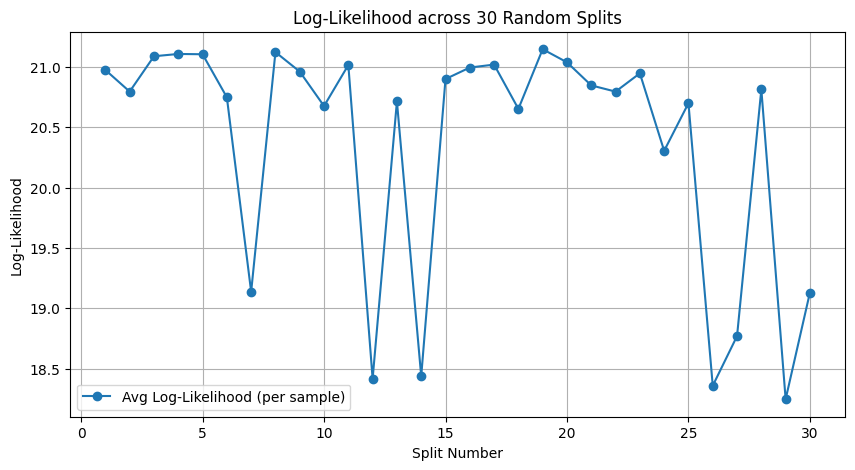

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_splits + 1), avg_log_likelihoods, marker='o', label="Avg Log-Likelihood (per sample)")
plt.title(f"Log-Likelihood across {n_splits} Random Splits")
plt.xlabel("Split Number")
plt.ylabel("Log-Likelihood")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
print(avg_log_likehoods)

NameError: name 'avg_log_likehoods' is not defined

In [14]:
from sklearn.metrics import mean_squared_error

# ---------- Hard assignment (predict) ----------
# Each sample is assigned to one cluster, reconstruction = cluster mean
X_scaled = scaler.fit_transform(df.values)
clusters = gmm.predict(X_scaled)
means = gmm.means_

# Reconstruction using hard cluster assignment
X_reconstructed_hard = means[clusters]

# Per-sample reconstruction error (MSE)
reconstruction_errors_hard = np.mean((X_scaled - X_reconstructed_hard) ** 2, axis=1)

# Mean reconstruction error
mean_reconstruction_error_hard = np.mean(reconstruction_errors_hard)


# ---------- Soft assignment (predict_proba) ----------
# Each sample gets probabilities for all clusters
probs = gmm.predict_proba(X_scaled)  # shape: (n_samples, n_components)

# Weighted average of cluster means = soft reconstruction
X_reconstructed_soft = probs @ means   # matrix multiplication

# Per-sample reconstruction error (MSE)
reconstruction_errors_soft = np.mean((X_scaled - X_reconstructed_soft) ** 2, axis=1)

# Mean reconstruction error
mean_reconstruction_error_soft = np.mean(reconstruction_errors_soft)


# ---------- Results ----------
print(f"Mean Hard Reconstruction Error: {mean_reconstruction_error_hard:.4f}")
print(f"Mean Soft Reconstruction Error: {mean_reconstruction_error_soft:.4f}")


C:\Users\B00804975\.conda\envs\tf_test\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
C:\Users\B00804975\.conda\envs\tf_test\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


Mean Hard Reconstruction Error: 1.2085
Mean Soft Reconstruction Error: 1.2085
